# FRB cosmology constrain from $DM_{IGM} $

Highly uncertain: $\Omega_b, f_{IGM}, \chi, w$ (If do wCDM cosmology)

For FRB, cosmology distance is based on the dispersion measure (DM), which defined as
$$ DM=\int_0^{D_z}\frac{n_e(l)}{1+z(l)}dl $$

DM can be splitted into multiple terms:
$$ DM=DM_{MW}+DM_{halo}+DM_{IGM}+\frac{DM_{host}+DM_{src}}{1+z}$$
where $DM_{MW}$ is the DM from the Milky Way, $DM_{halo}$ is the DM from the halo, $DM_{IGM}$ is the DM from the intergalactic medium, $DM_{host}$ is the DM from the host galaxy, and $DM_{src}$ is the DM from the source.

$DM_{MW}$ can be derived from model. $DM_{halo} \sim (30-80)pc \; cm^{-3}$

Most important is the IGM component:
$$ <DM_{IGM}>=\frac{3cH_0 \Omega_b }{8\pi G m_p}\int_0^z \frac{f_{IGM}\chi(z')(1+z')dz'}{E(z')}$$
Here,
$$\chi=Y_H X_{e,H}+\frac{1}{2}Y_{He} X_{e,He}$$
Recall $Y_H=1/4$ and $Y_{He}=3/4$.

According to [[Bei Zhou 2014](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.89.107303)], $z\lesssim 3$, $X_{e,H}=X_{e,He}=1$; at $z\gtrsim 1.5$ $f_{IGM}\approx 90\%$; as $z\leq 0.4$ $f_{IGM}\approx (82\pm 4)\%$ [[Lin \& Zoo](https://arxiv.org/pdf/2302.10585), which also includes redshift dependence].

H fully ionized ($\chi_{e,H}=1)$ at $ z<6 $ ([Fan 2006](https://www.annualreviews.org/content/journals/10.1146/annurev.astro.44.051905.092514)), He fully ionized ($\chi_{e,He}=1$) at $ z<2$ ([McQuinn 2009](https://ui.adsabs.harvard.edu/abs/2009ApJ...694..842M/abstract))

In [2]:
import sys
sys.path.append('../Python_scripts')

## Import packages
from config import *
from support import *
from cosmo_support import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### Load the FRB data, from Macquart+ 2020

In [3]:
data=pd.read_csv('../Data/FRB_Macquart_org.csv')
data

,FRB,z,DM_ext,DM
0,FRB 20180924,0.3214,281.42,361.42
1,FRB 20181112,0.4755,509.27,589.27
2,FRB 20190102,0.2910,283.60,363.60
3,FRB 20190608,0.1178,258.70,338.70
4,FRB 20190711,0.5220,513.10,593.10


We first perform the original corrections based on the assumptions of Macquart et al., to plot the ${\rm DM}$ vs $z$ relation.

In [4]:
## We are correcting for the ISM (30 pc/cm^3), MW (50 pc/cm^3) and host (50/(1+z) pc/cm^3)

DM_corrected_Macquart = data['DM']-50-30-50/(1+data['z'])

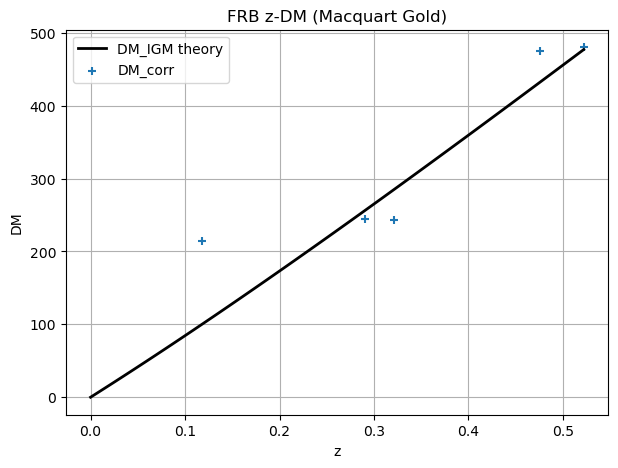

In [5]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(111)

z_range = np.linspace(0, np.max(data['z']), 100)

DM_theory = np.zeros_like(z_range)
for idx, redshift in enumerate(z_range):
    DM_theory[idx] = dispersion_measure(redshift, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = f_IGM)

ax1.plot(z_range, DM_theory, lw=2, c='black', label='DM_IGM theory')
ax1.scatter(data['z'], DM_corrected_Macquart, s=40, marker='+', label='DM_corr')  
ax1.set_xlabel('z')
ax1.set_ylabel('DM')
ax1.set_title('FRB z-DM (Macquart Gold)')
ax1.grid(True)
ax1.legend()


plt.show()

**NB**: Compare this with their *Fig.2*. Or an updated version [[here](https://github.com/FRBs/FRB/blob/main/docs/nb/Macquart_Relation.ipynb)] that looks much more similar with our result. The $f_{\rm IGM}$ modelling affects importantly the prediction of the theoretical line. The DMs reported here are consistent with the published DMs.

## The simplest case: $\chi^2$ with a single DM parameter

- For the dispersion measure:

We have contributions from the MW ${\rm DM}_{\rm MW}$, the observational limitations ${\rm DM}_{\rm obs}$, the intergalactic medium ${\rm DM}_{\rm IGM}$, the host galaxy ${\rm DM}_{\rm host}$ and potentially the source itself ${\rm DM}_{\rm host}$. Some fiducial values based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)] are [in pc/cm$^3$]:

$$
\sigma_{\rm MW} \sim 10, \quad \sigma_{\rm obs} \sim 1.5, \quad \sigma_{\rm IGM} \sim 100, \quad \sigma_{\rm host} \sim 30,
$$

$$
\sigma_{\rm DM_{IGM}} = \sqrt{\sigma_{\rm obs}^2+\sigma_{\rm MW}^2+\sigma_{\rm IGM}^2+\left(\frac{\sigma_{\rm host}}{1+z}\right)^2},
$$

consider uncertainty in Jun-jie Wei's paper first. We are using the values for Macquart+ below:

In [6]:
## Fiducial value for H0*Ωb*f_IGM
F_fid=HUBBLE*OMEGA_BARYONS*f_IGM
print(f'Fiducial F value is: {F_fid}.')

Fiducial F value is: 2.7831805679999997.


We perform a $\chi^2$ analysis to find the uncertainty of $F = H_0 \Omega_b f_{\rm IGM}$.

In [7]:
F_array=np.linspace(0.1, 10, 1000)

## Create array to store values
Chi_fid=np.zeros_like(F_array)
sigma_vec=np.vectorize(sigma_DM_IGM)
DM_vec=np.vectorize(dispersion_measure)

## Chi^2 test
for idx, F in enumerate(F_array):
    sigma=sigma_vec(data['z'])
    
    ## We divide here by OMEGA_BARYONs and set f_IGM_0=1, due to the way we have defined the function
    DM_th=DM_vec(data['z'], H0=F/OMEGA_BARYONS, Om=OMEGA_MATTER, alpha=0.11, f_IGM_0 = 1)
    Chi_fid[idx]=np.sum((DM_corrected_Macquart-DM_th)**2/sigma**2)

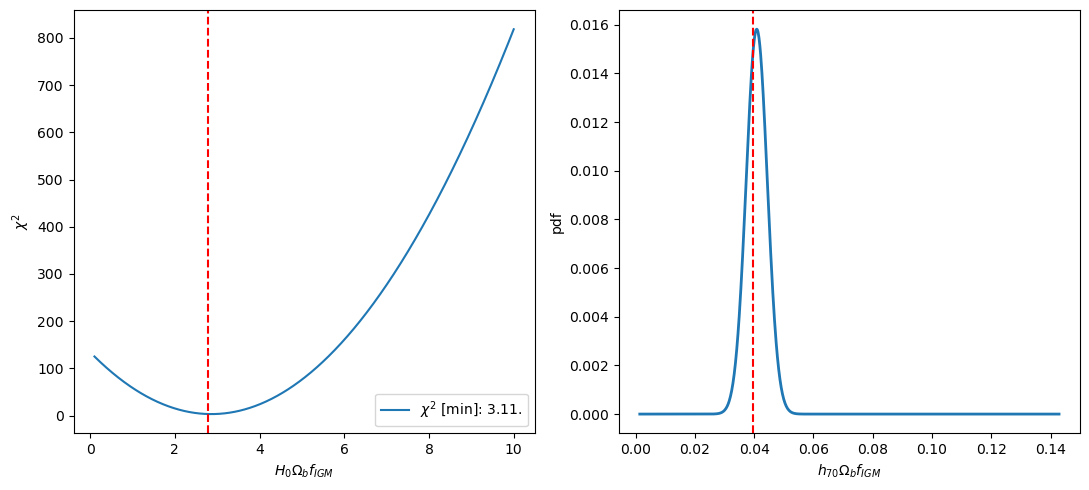

In [8]:
fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(F_array, Chi_fid, label=fr'$\chi^2$ [min]: {round(np.min(Chi_fid), 2)}.')
ax1.axvline(F_fid, color='r', linestyle='--')
ax1.set_ylabel(r'$\chi^2$')
ax1.set_xlabel(r'$H_0 \Omega_b f_{IGM}$')
ax1.legend()

ax2.plot(F_array/70, normalise(np.exp(-Chi_fid/2)), lw=2)
ax2.axvline(F_fid/70, color='r', linestyle='--')
ax2.set_xlabel(r'$h_{70} \Omega_b f_{IGM}$')
ax2.set_ylabel(r'pdf')

plt.tight_layout()
plt.show()

**NB**: 

1. In reality, the 'fiducial' value of $H_0 \Omega_b f_{\rm IGM}$, assumes some prior observations/knowledge on these quantities. So it is slightly arbitrary - the data are not simulated based on this value, i.e. there is no guarantee that they recover it.

2. Compare with Macquart+, *Fig. 3b*. (note the slightly different axes though). 

3. We usually expect $\chi^2_{\rm min} \sim N$, where $N$ are the degrees of freedom. In our case, they would be $N=5-1=4$. This can depend on the model, but also, quite possibly on the error analysis.

## Reproduce Macquart+ 2020 corner plot

We first need to introduce Macquart+ pdfs for $DM_{\rm host}$ and $DM_{\rm cosmic}$.

$$ DM=DM_{MW, ISM}+DM_{MW, halo}+DM_{cosmic, IGM}+DM_{host}$$

$ DM_{halo}\approx 50 pc\,cm^{-3} $

$ DM_{MW, ISM}=30 pc\,cm^{-3} $ high Galactic latitudes

--------------------------------

**Pdf for host dispersion measure**

$$
p_{host}(DM_{host}|\mu,\sigma_{host})=\frac{1}{\sqrt{2\pi} \cdot DM \cdot \sigma_{host}}\exp\left[-\frac{(\log DM-\mu)^2}{2\sigma_{host}^2}\right],
$$

with median value of $ \exp^\mu$ and variance $ \exp\{(\mu+\sigma_{host}^2)/2\} (\exp\{\sigma_{host}^2\}-1)^{1/2}$.

**NB**: $DM = DM_{host}/(1+z) $

1. Reproducing *Extended Data Fig.2*

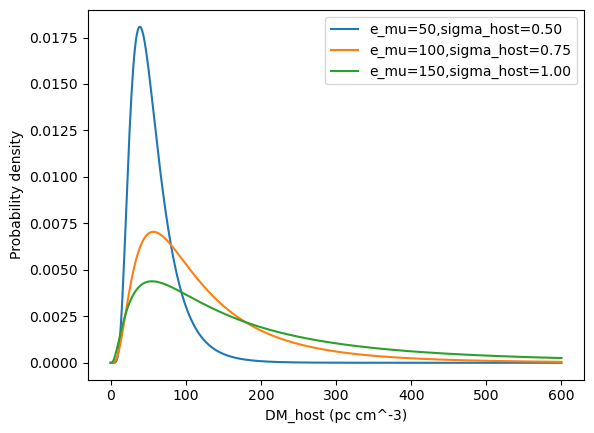

In [9]:
DM_host=np.linspace(0.01, 600, 500)
p1=pdf_DM_host(DM_host,e_mu=50,sigma_host=0.50)
p2=pdf_DM_host(DM_host,e_mu=100,sigma_host=0.75)
p3=pdf_DM_host(DM_host,e_mu=150,sigma_host=1.00)

plt.plot(DM_host,p1,label='e_mu=50,sigma_host=0.50')
plt.plot(DM_host,p2,label='e_mu=100,sigma_host=0.75')
plt.plot(DM_host,p3,label='e_mu=150,sigma_host=1.00')
plt.xlabel('DM_host (pc cm^-3)')
plt.ylabel('Probability density')
plt.legend()
plt.show()

Checking normalisation of `pdf_DM_host`

In [10]:
np.trapz(p1, x=DM_host), np.trapz(p2, x=DM_host), np.trapz(p3, x=DM_host)

(0.9999996649016938, 0.9915530964122932, 0.9171713532681247)

Checking array operations with `pdf_DM_host`

In [11]:
e_mu_array = np.linspace(50, 150, 50)
sigma_h_array = np.linspace(0.5, 1.0, 10)

em_, sh_ = np.meshgrid(e_mu_array, sigma_h_array)

In [12]:
pdf_DM_host(10, e_mu=em_, sigma_host=sh_).shape

(10, 50)

**NB**: We can pass ND arrays in `pdf_DM_host`. This could be useful, speeding up the final likelihood calculations.

--------------------------------

**Pdf for cosmic dispersion measure**

$$
p_{cosmic, IGM}(\Delta)=A\Delta^{-\beta}\exp\left(-\frac{(\Delta^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right) 
$$

- $ \sigma_{DM} $ dominated by physical variance in $DM_{cosmic}$

- $\Delta=DM_{cosmic}/\langle DM_{cosmic} \rangle$, $\Delta>0$.

- $ \sigma_{DM}=Fz^{-0.5} $

Whith 3D density profile scales as $ \rho \propto r^{-\alpha} $, we have $\beta=(\alpha+1)/(\alpha-1)$. We fix: $\alpha=3$ and $\beta=3$.

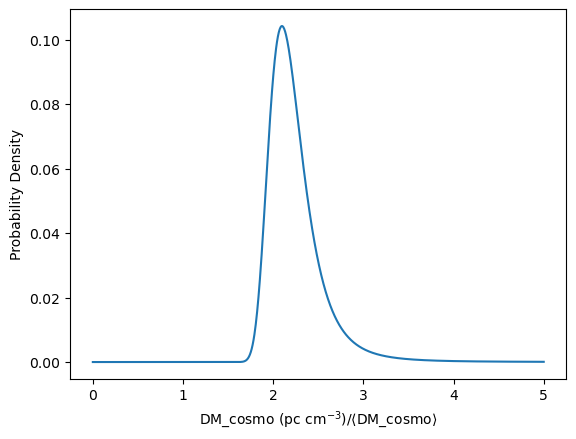

In [13]:
DM_cos=np.linspace(0.001,5,1000)
p=pdf_DM_cosmo(DM_cos, C_0=0.1, A=1, sigma=0.01)

plt.plot(DM_cos,p)
plt.xlabel(r'DM_cosmo (pc cm$^{-3}$)/$\langle$DM_cosmo$\rangle$')
plt.ylabel('Probability Density')
plt.show()

Two constants still not known: $A $ and $ C_0$. 

According to the paper, $C_0$ is constrain by the $\langle x \rangle=\int xp dx=1$. considering pdf, we also have $ \int p dx=1$, which help us to find $ C_0$ and $A$.

$ \int p_{cosmic, IGM}(x) dx=\int A x^{-\beta}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx=1 $

$ \int x p_{cosmic, IGM}(x) dx=\int A x^{-\beta+1}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx=1 $

When we do:

$ \frac{\int x p_{cosmic, IGM}(x) dx}{\int p_{cosmic, IGM}(x) dx}=\frac{\int A x^{-\beta+1}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx}{\int A x^{-\beta}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx}=1 $

**Find $C_0$**:

Equavalent to: 

$ \int x \cdot p_{cosmic, IGM}(x) dx - \int p_{cosmic, IGM}(x) dx=0 $

Using this equation to do numerical calculation.

If use $ \int (x-1) p_{cosmic, IGM}(x) dx=0 $ to find C_0 will cost more time.

$A$ cancels out so we can solve for $C_0$. 

**Find $A$**:

As for $A$, when we have $C_0$,we have:

$ A=\frac{A}{\int p_{cosmic, IGM}(x) dx}=\frac{1}{\int x^{-\beta}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx} $

First, let's find $C_0$:

- Use our numerical method, described above
- use data from the `FRB` package [[here](https://github.com/FRBs/FRB/tree/main)]

In [14]:
sigmas=np.linspace(0.001, 1.8, 75)
C0s=np.zeros_like(sigmas)
C0s_smaller_int_range=np.zeros_like(sigmas)


for i, sigma in enumerate(sigmas):
    C0s[i]=C0_sigma(sigma)
    C0s_smaller_int_range[i]=C0_sigma(sigma, x_min=1/400, x_max=55)

In [15]:
sigma_C0_beta3 = pd.read_csv('../Data/sigma_C0_beta3.ascii', delimiter="|")

sigmas_ascii = np.array(sigma_C0_beta3.iloc[:, 1])
C0_ascii = np.array(sigma_C0_beta3.iloc[:, 2])

## Interpolated function
f_C0_ascii = interpolate.interp1d(sigmas_ascii[sigmas_ascii<1.8], C0_ascii[sigmas_ascii<1.8], kind='cubic')

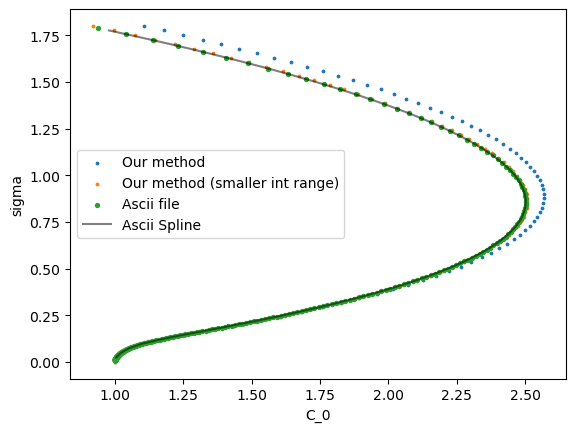

In [16]:
plt.scatter(C0s, sigmas, s=3, label='Our method')
plt.scatter(C0s_smaller_int_range, sigmas, s=3, label='Our method (smaller int range)')

plt.scatter(C0_ascii[sigmas_ascii<1.8], sigmas_ascii[sigmas_ascii<1.8], s=8, label='Ascii file')

plt.plot(f_C0_ascii(sigmas[(0.01<sigmas)*(sigmas<1.78)]), sigmas[(0.01<sigmas)*(sigmas<1.78)],\
         alpha=0.5, c='black', label='Ascii Spline')


plt.ylabel('sigma')
plt.xlabel('C_0')
plt.legend()

plt.show()

**NB**: There is a difference between our pairs of $(\sigma, C_0)$, and we have checked that this is highly dependent on the integration limits used when estimating $C_0$ (see relevant equations above).

Let's check how well our interpolation performs

In [17]:
Zs = np.linspace(0.01, 2, 70)

lista_acc = np.zeros_like(Zs)
lista_int = np.zeros_like(Zs)

for idx, Z in enumerate(Zs):
    C_0 = find_C0(F=0.1, z=Z, sigmas=sigmas, C0s=C0s, method="acc")
    lista_acc[idx] = C_0
    C_0 = find_C0(F=0.1, z=Z, sigmas=sigmas, C0s=C0s)
    lista_int[idx] = C_0

Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate method
Do accurate 

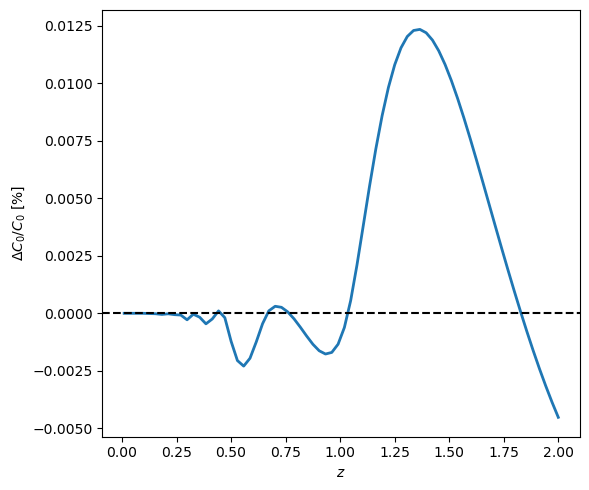

In [18]:
fig= plt.figure(figsize=(6,5))
ax1 = fig.add_subplot(1, 1, 1)

ax1.plot(Zs, (lista_int-lista_acc)/lista_acc*100,\
         c='tab:blue', lw=2)
ax1.axhline(y=0, ls='--', c='black')
ax1.set_xlabel(r"$z$")
ax1.set_ylabel(r"$\Delta C_{0}/C_0$ [%]")

plt.tight_layout()
plt.show()

**NB** - Our interpolation procedure is very effective, with $<1\%$ errors for different redshifts.

In [19]:
import timeit

In [20]:
print("\n Timing to find C0, using interpolation:")
%timeit find_C0(F=0.1, z=1, sigmas=sigmas, C0s=C0s)


 Timing to find C0, using interpolation:
85.9 µs ± 2.74 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Now let's try to find $A$ (the normalisation of the pdf)

1. Test 1

In [21]:
## Finding first a test C0
C0_test = find_C0(F=0.3044, z=1, sigmas=sigmas, C0s=C0s)
print(f"Test C0 is: {C0_test}")

## Finding a test A
A_test = find_A(C_0, F=0.3044, z=1)
print(f"Test A is: {A_test}")

## Checking if the normalisation is correct
sigma = f_sigma_DM(F=0.3044, z=1)
print(f"Norm pdf is: {quad(lambda x: pdf_DM_cosmo(x, C0_test, A_test, sigma, 3, 3), 0., np.inf)[0]}.")
print(f"Mean pdf is: {quad(lambda x: x*pdf_DM_cosmo(x, C0_test, A_test, sigma, 3, 3), 0., np.inf)[0]}.")

Test C0 is: 1.7902477659296758
Test A is: 1.4003832996852792
Norm pdf is: 0.9234686795960946.
Mean pdf is: 0.9234687077559206.


2. Test 2

In [22]:
z=0.2
F=0.3

C0_test=find_C0(F=F,z=z, sigmas=sigmas, C0s=C0s)
A_test=find_A(C_0=C0_test,F=F,z=z)
print(f"Test C0 is: {C0_test}")
print(f"Test A is: {A_test}")

sigma = f_sigma_DM(F,z)
print(f"Norm pdf is: {quad(lambda x: pdf_DM_cosmo(x, C0_test, A_test, sigma, 3, 3), 0., np.inf)[0]}.")
print(f"Mean pdf is: {quad(lambda x: x*pdf_DM_cosmo(x, C0_test, A_test, sigma, 3, 3), 0., np.inf)[0]}.")

Test C0 is: 2.4703923427023806
Test A is: 0.8281161405471799
Norm pdf is: 0.9999999999999999.
Mean pdf is: 0.9999999985497949.


**NB**: In *Test 1* the results are worse, so this means that the values of $(F, z)$ can play a role in the accuracy.

### We start comparing with the Macquart+ paper, by reproducing *Extended Fig. 3*.

In [23]:
DMs=np.linspace(30, 4000, 8000)
zs=np.array([0.1,0.2,0.5,1.0])

p_DM=pd.DataFrame(columns=zs)
vec_DM_cosmo=np.vectorize(pdf_DM_cosmo)

F=0.32  # This corresponds to their top row

for z in zs:
    C_0 = find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s)
    A = find_A(C_0=C_0, F=F, z=z)
    DM_mean=dispersion_measure(z=z, H0=HUBBLE, Om=OMEGA_MATTER)
    
    p_cosmic = vec_DM_cosmo(Delta=DMs/DM_mean, C_0=C_0, A=A, sigma=f_sigma_DM(F,z))
    print("Checking that the pdfs have the correct norm and mean:")
    print(f"Norm: {np.trapz(p_cosmic, x=DMs/DM_mean)}, Mean: {np.trapz(DMs/DM_mean*p_cosmic, x=DMs/DM_mean)}.\n")
    
    p_DM[z]=DMs/DM_mean*p_cosmic

Checking that the pdfs have the correct norm and mean:
Norm: 0.9998995649924675, Mean: 0.9904864454588043.

Checking that the pdfs have the correct norm and mean:
Norm: 0.9996246162286307, Mean: 0.982657815983679.

Checking that the pdfs have the correct norm and mean:
Norm: 0.9979597250504396, Mean: 0.9641944139049571.

Checking that the pdfs have the correct norm and mean:
Norm: 0.9934059501798846, Mean: 0.9443424558061262.



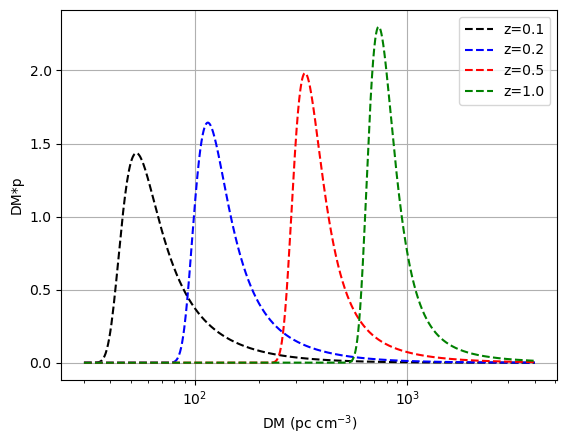

In [24]:
plt.plot(DMs,p_DM[zs[0]],label='z=0.1', c='black', ls='--')
plt.plot(DMs,p_DM[zs[1]],label='z=0.2', c='blue', ls='--')
plt.plot(DMs,p_DM[zs[2]],label='z=0.5', c='red', ls='--')
plt.plot(DMs,p_DM[zs[3]],label='z=1.0', c='green', ls='--')
plt.xlabel('DM (pc cm$^{-3}$)')
plt.ylabel('DM*p')
plt.xscale('log')
plt.grid(True)
plt.legend()
plt.show()

In [25]:
DMs=np.linspace(30, 4000, 8000)
Fs=np.array([0.32, 0.15, 0.09])

p_DM_fid=pd.DataFrame(columns=Fs)
p_DM_high_fIGM=pd.DataFrame(columns=Fs)
vec_DM_cosmo=np.vectorize(pdf_DM_cosmo)

z=0.5  # This corresponds to the red distribution in all rows


for F in Fs:
    C_0 = find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s)
    A = find_A(C_0=C_0,F=F,z=z)
    DM_mean=dispersion_measure(z=z, H0=HUBBLE, Om=OMEGA_MATTER)
    
    p_cosmic = vec_DM_cosmo(Delta=DMs/DM_mean, C_0=C_0, A=A, sigma=f_sigma_DM(F,z))
    print("Checking that the pdfs have the correct norm and mean:")
    print(f"Norm: {np.trapz(p_cosmic, x=DMs/DM_mean)}, Mean: {np.trapz(DMs/DM_mean*p_cosmic, x=DMs/DM_mean)}.\n")

    p_DM_fid[F]=DMs/DM_mean*p_cosmic
    
    
    DM_mean_high_fIGM=dispersion_measure(z=z, H0=HUBBLE, Om=OMEGA_MATTER, f_IGM_0=0.94)
    
    p_cosmic = vec_DM_cosmo(Delta=DMs/DM_mean_high_fIGM, C_0=C_0, A=A, sigma=f_sigma_DM(F,z))
    print("Checking that the pdfs have the correct norm and mean:")
    print(f"Norm: {np.trapz(p_cosmic, x=DMs/DM_mean_high_fIGM)}, Mean: {np.trapz(DMs/DM_mean_high_fIGM*p_cosmic, x=DMs/DM_mean_high_fIGM)}.\n")

    p_DM_high_fIGM[F]=DMs/DM_mean_high_fIGM*p_cosmic

Checking that the pdfs have the correct norm and mean:
Norm: 0.9979597250504396, Mean: 0.9641944139049571.

Checking that the pdfs have the correct norm and mean:
Norm: 0.9974443207711792, Mean: 0.9599248932550348.

Checking that the pdfs have the correct norm and mean:
Norm: 0.9991481899433354, Mean: 0.9850601266605873.

Checking that the pdfs have the correct norm and mean:
Norm: 0.9989323712401476, Mean: 0.9832723465080945.

Checking that the pdfs have the correct norm and mean:
Norm: 0.9998325636752705, Mean: 0.9970723942443663.

Checking that the pdfs have the correct norm and mean:
Norm: 0.9997899182465171, Mean: 0.996719140490684.



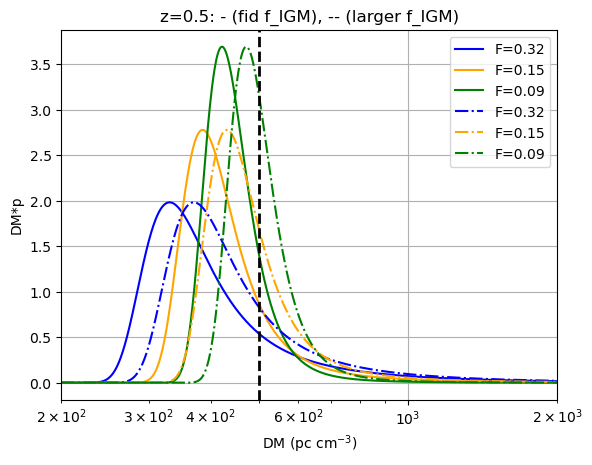

In [26]:
plt.plot(DMs,p_DM_fid[Fs[0]],label='F=0.32', c='blue')
plt.plot(DMs,p_DM_fid[Fs[1]],label='F=0.15', c='orange')
plt.plot(DMs,p_DM_fid[Fs[2]],label='F=0.09', c='green')

plt.plot(DMs,p_DM_high_fIGM[Fs[0]],label='F=0.32', ls='-.', c='blue')
plt.plot(DMs,p_DM_high_fIGM[Fs[1]],label='F=0.15', ls='-.', c='orange')
plt.plot(DMs,p_DM_high_fIGM[Fs[2]],label='F=0.09', ls='-.', c='green')

plt.axvline(x=500, ls='--', c='black', lw=2)

plt.xlabel('DM (pc cm$^{-3}$)')
plt.ylabel('DM*p')
plt.xscale('log')
plt.xlim(200, 2*10**3)
plt.grid(True)
plt.title('z=0.5: - (fid f_IGM), -- (larger f_IGM)')
plt.legend()

plt.show()

Can we input `np.arrays` in `pdf_DM_cosmo`?

In [27]:
F_array=np.linspace(0.01, 0.5, 5)
sigma_F = f_sigma_DM(F_array, 0.5)

In [28]:
C0s_array = find_C0(F=F_array, z=0.5, sigmas=sigmas, C0s=C0s)

In [29]:
pdf_DM_cosmo(Delta=500, C_0=C0s_array, A=1, sigma=sigma_F)

array([6.50925639e-130, 3.53093488e-010, 1.59139492e-009, 2.85222242e-009,
       3.99319551e-009])

**NB**: Not all calculations of `pdf_DM_cosmic` allow for array manipulations, due to integrations. We can avoid some of these, like the calculation of $A$, i.e. the normalisation of `pdf_DM_cosmic` - we could do this at the end, when normalising the full probability.

--------------------------------------------------

### We compare with the Macquart+ paper, by reproducing *Fig. 3*.

In [30]:
## let's remember the data:
## Exactly 5 golden FRBs in Macquart paper, DM_ext=DM-30-50, which is DM_MW and DM_ISM in their paper
data

,FRB,z,DM_ext,DM
0,FRB 20180924,0.3214,281.42,361.42
1,FRB 20181112,0.4755,509.27,589.27
2,FRB 20190102,0.2910,283.60,363.60
3,FRB 20190608,0.1178,258.70,338.70
4,FRB 20190711,0.5220,513.10,593.10


**Calculation of the total likelihood**

$ DM'_{FRB}=DM_{FRB}-DM_{MW, ISM}-DM_{MW, halo}=DM_{host}+DM_{cosmic} $

$ P_i(DM'_{FRB,i}|z_i)=\int_0^{DM'_{FRB,i}} p_{host}(DM_{host}|\mu, \sigma_{host})p_{cosmic}(DM'_{FRB,i}-DM_{host}, z_i)d DM_{host}$

$ \mathcal{L} = \prod_{i=1}^{N_{\text{FRBs}}} P_i(\text{DM}'_{\text{FRB}} | z_i) $


Note actually:

$ DM'_{FRB}=DM_{FRB}-DM_{MW, ISM}-DM_{MW, halo}=\frac{DM_{host}}{1+z}+DM_{cosmic} $

so:

$ P_i(DM'_{FRB,i}|z_i)=\int_0^{DM'_{FRB,i}} p_{host}(DM_{host}|\mu, \sigma_{host})p_{cosmic}(DM'_{FRB,i}-\frac{DM_{host}}{1+z_i}, z_i)d DM_{host}$

In [31]:
### Comparing the standard calculation of <DM_cosmic> in the two different parameterisations

## The classic DM measure:
print(dispersion_measure(1, HUBBLE, OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = f_IGM))

## The updated function, to cover Ωbh70
print(DM_IGM_O_bh_70(1, HUBBLE/70*OMEGA_BARYONS, OMEGA_MATTER, -1, alpha=0.11, f_IGM_0 = f_IGM))

944.0949564541277
944.0949564541276


----------------------------------------------------------------

**MK** - To update below:



In [32]:
def calculate_dm_probability_macquart(DM_frb_max, z, F, O_bh_70, e_mu, sigma_host, alpha=0.11, f_IGM_0=f_IGM):
    """
    This version follows exactly Macquart+ procedure, 
    eq. (5)-(7) in [arXiv:2005.13161].    
    """
    
    DM_frb_array = np.linspace(0.01, DM_frb_max-0.01, 5000)
    
    ## Host calculation
    pdf_host = pdf_DM_host(DM_frb_array, e_mu, sigma_host)
    
    ## Cosmic calculation
    DM_cosmic = DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1, alpha=alpha, f_IGM_0=f_IGM_0)
    
    Deltas = (DM_frb_max-DM_frb_array)/DM_cosmic
    C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s)
    A = find_A(C_0=C_0, F=F, z=z)
    pdf_cosmic = pdf_DM_cosmo(Deltas, C_0, A=A, sigma=f_sigma_DM(F,z))
    
    ## Combine together
    prob = np.trapz(pdf_host*pdf_cosmic, x=DM_frb_array)
    
    ## Transform to probabilities
    dDM = np.abs(np.diff(DM_frb_array)[0])/DM_cosmic
    
    return prob*dDM

In [33]:
def calculate_dm_probability_macquart_v2(DM_frb_max, z, F, O_bh_70, e_mu, sigma_host, alpha=0.11, f_IGM_0=f_IGM):
    """
    This version follows exactly Macquart+ procedure, 
    eq. (5)-(7) in [arXiv:2005.13161].    
    """
    
    DM_frb_array = np.linspace(0.01, DM_frb_max-0.01, 5000)/(1+z)
    
    ## Host calculation
    pdf_host = pdf_DM_host(DM_frb_array*(1+z), e_mu, sigma_host)
    
    ## Cosmic calculation
    DM_cosmic = DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1, alpha=alpha, f_IGM_0=f_IGM_0)
    
    Deltas = (DM_frb_max-DM_frb_array*(1+z))/DM_cosmic
    C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s)
    A = find_A(C_0=C_0, F=F, z=z)
    pdf_cosmic = pdf_DM_cosmo(Deltas, C_0, A=A, sigma=f_sigma_DM(F,z))
    
    ## Combine together
    prob = np.trapz(pdf_host*pdf_cosmic, x=DM_frb_array)*(1+z)
    
    ## Transform to probabilities
    dDM = np.abs(np.diff(DM_frb_array*(1+z))[0])/DM_cosmic
    
    return prob*dDM

In [34]:
def calculate_dm_probability_macquart_v3(DM_frb_max, z, F, O_bh_70, e_mu, sigma_host, alpha=0.11, f_IGM_0=f_IGM):
    """
    This version follows exactly Macquart+ procedure, 
    eq. (5)-(7) in [arXiv:2005.13161].    
    """
    
    DM_frb_array = np.linspace(0.01, DM_frb_max-0.01, 5000)
    
    ## Host calculation
    pdf_host = pdf_DM_host(DM_frb_array, e_mu, sigma_host)
    
    ## Cosmic calculation
    DM_cosmic = DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1, alpha=alpha, f_IGM_0=f_IGM_0)
    
    Deltas = (DM_frb_max-DM_frb_array/(1+z))/DM_cosmic
    C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s)
    A = find_A(C_0=C_0, F=F, z=z)
    pdf_cosmic = pdf_DM_cosmo(Deltas, C_0, A=A, sigma=f_sigma_DM(F,z))
    
    ## Combine together
    prob = np.trapz(pdf_host*pdf_cosmic, x=DM_frb_array)
    
    ## Transform to probabilities
    dDM = np.abs(np.diff(DM_frb_array)[0])/DM_cosmic
    
    return prob*dDM

In [35]:
def calculate_dm_probability_macquart_v4(DM_frb_max, z, F, O_bh_70, e_mu, sigma_host, alpha=0.11, f_IGM_0=f_IGM):
    """
    This version follows exactly Macquart+ procedure, 
    eq. (5)-(7) in [arXiv:2005.13161].    
    """
    
    DM_frb_array = np.linspace(0.01, DM_frb_max-0.01, 5000)
    
    ## Host calculation
    pdf_host = pdf_DM_host(DM_frb_array/(1+z), e_mu, sigma_host)
    
    ## Cosmic calculation
    DM_cosmic = DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1, alpha=alpha, f_IGM_0=f_IGM_0)
    
    Deltas = (DM_frb_max-DM_frb_array/(1+z))/DM_cosmic
    C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s)
    A = find_A(C_0=C_0, F=F, z=z)
    pdf_cosmic = pdf_DM_cosmo(Deltas, C_0, A=A, sigma=f_sigma_DM(F,z))
    
    ## Combine together
    prob = np.trapz(pdf_host*pdf_cosmic, x=DM_frb_array)
    
    ## Transform to probabilities
    dDM = np.abs(np.diff(DM_frb_array)[0])/DM_cosmic
    
    return prob*dDM

In [36]:
def calculate_dm_probability_fast(DM_frb_max, z, F, O_bh_70, e_mu, sigma_host, alpha=0.11, f_IGM_0=f_IGM):
    """
    This version follows exactly Macquart+ procedure, 
    eq. (5)-(7) in [arXiv:2005.13161], but transforms
    to a dMc variable.
    
    The (1+z) factor comes from the Jacobian, due to 
    the reparameterisation.
    """
    
    DM_frb_array = np.linspace(0.01, DM_frb_max-0.01, 5000)

    ## Host calculation
    DM_host = (DM_frb_max-DM_frb_array)*(1+z)
    pdf_host = pdf_DM_host(DM_host, e_mu, sigma_host)
    
    ## Cosmic calculation
    DM_cosmic = DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1, alpha=alpha, f_IGM_0=f_IGM_0)
    
    Deltas = (DM_frb_array)/DM_cosmic
    C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s)
    A = find_A(C_0=C_0, F=F, z=z, alpha=3, beta=3)
    pdf_cosmic = pdf_DM_cosmo(Deltas, C_0, A=A, sigma=f_sigma_DM(F,z))
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=DM_frb_array)*(1+z)
    
    ## Transform to probabilities
    dDM = np.abs(np.diff(DM_frb_array)[0])/DM_cosmic
    
    return prob*dDM

Consider $p_{host}$ is in the rest/comoving frame, one can have $\int_0^{FRB'(1+z)}p_{host}(DM_{host})p_{IGM}(\frac{DM-\frac{DM_{host}}{1+z}}{<DM>})$. Here the upper limit is modified by (1+z) to make sure $p_{IGM}$ be integrated from 0 to $FRB'$. However, this is not in unit of probability. This is just something like convolution of two PDF. To make sure we get probability, here we times the integration step of $p_{IGM}$, which is $d(\frac{DM-\frac{DM_{host}}{1+z}}{<DM>})=\frac{dDM_{host}}{(1+z)<DM>}$

In [37]:
def calculate_dm_probability_fast_v2(DM_frb_max, z, F, O_bh_70, e_mu, sigma_host, alpha=0.11, f_IGM_0=f_IGM):
    """
    This version follows exactly Macquart+ procedure, 
    eq. (5)-(7) in [arXiv:2005.13161], but transforms
    to a dMc variable.
    
    fast version for integrate DM_host, considering integration from 0 to DM'(1+z) to let DM_IGM from 0 to DM'
    """
    
    DM_frb_array = np.linspace(0.01, DM_frb_max-0.01, 5000)

    ## Host calculation
    pdf_host = pdf_DM_host(DM_frb_array, e_mu, sigma_host)
    
    ## Cosmic calculation
    DM_cosmic = DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1, alpha=alpha, f_IGM_0=f_IGM_0)
    
    Deltas = (DM_frb_max-DM_frb_array/(1+z))/DM_cosmic
    C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s)
    A = find_A(C_0=C_0, F=F, z=z, alpha=3, beta=3)
    pdf_cosmic = pdf_DM_cosmo(Deltas, C_0, A=A, sigma=f_sigma_DM(F,z))
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=DM_frb_array*(1+z))
    
    ## Transform to probabilities
    dDM = np.abs(np.diff(DM_frb_array)[0])/DM_cosmic/(1+z)
    
    return prob*dDM

In [38]:
def calculate_dm_probability(DM_frb, z, F, O_bh_70, sigma_host, e_mu):
    """
    Calculate the probability of DM_FRB given various cosmological parameters
    
    Parameters:
    -----------
    DM_frb : float
        The observed DM_FRB value
    z : float
        Redshift
    F : float
        Structure factor parameter
    O_bh_70 : float
        Baryon density parameter
    sigma_host : float
        Standard deviation of host DM distribution
    e_mu : float
        Mean of host DM distribution
    
    Returns:
    --------
    float
        The calculated probability
    """
    
    def integrand(DM_host):
        # Calculate p_host at the current dm_host value
        # p_host_val = pdf_DM_host(DM_host, e_mu, sigma_host)
        C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s)
        
        if C_0 is None:
            print(f"Error: find_C0 C_0 is None, when F={F}, z={z}")
            return 0.0
            
        try:
            A = find_A(C_0=C_0, F=F, z=z)
        except:
            print(f"Error: find_A, when F={F}, z={z}")
            return 0.0
        
        if A is None:
            print(f"Error: C_0={C_0} or A={A}, when F={F}, z={z}")
            return 0.0
        
        # Calculate delta parameter
        delta=(DM_frb-DM_host/(1+z))/DM_IGM_O_bh_70(z=z,O_bh_70=O_bh_70)
        p_cosmic_val = pdf_DM_cosmo(Delta=delta, C_0=C_0, A=A, sigma=f_sigma_DM(F,z))
        
        p_host_val = pdf_DM_host(DM_host, e_mu, sigma_host)
        
        return p_host_val * p_cosmic_val
    
    # Perform the integration from 0.01 to DM_FRB
    result, error = quad(integrand, 0.01, DM_frb*(1+z))
    
    return result/DM_IGM_O_bh_70(z=z,O_bh_70=O_bh_70)

Check that all give the same result, in probabilities:

In [39]:
print(calculate_dm_probability_fast(DM_frb_max=509.27,z=0.4755,F=0.2,O_bh_70=0.06,sigma_host=0.3,e_mu=60))

0.0004655481031080148


In [40]:
print(calculate_dm_probability_fast_v2(DM_frb_max=509.27,z=0.4755,F=0.2,O_bh_70=0.06,sigma_host=0.3,e_mu=60))

0.00046554810310801484


In [41]:
print(calculate_dm_probability_macquart(DM_frb_max=509.27,z=0.4755,F=0.2,O_bh_70=0.06,sigma_host=0.3,e_mu=60))

0.0005159071183881593


In [42]:
print(calculate_dm_probability_macquart_v2(DM_frb_max=509.27,z=0.4755,F=0.2,O_bh_70=0.06,sigma_host=0.3,e_mu=60))

0.0005159071183881592


In [43]:
print(calculate_dm_probability_macquart_v3(DM_frb_max=509.27,z=0.4755,F=0.2,O_bh_70=0.06,sigma_host=0.3,e_mu=60))

0.0004655481031080148


In [44]:
print(calculate_dm_probability_macquart_v4(DM_frb_max=509.27,z=0.4755,F=0.2,O_bh_70=0.06,sigma_host=0.3,e_mu=60))

0.0007612209531817291


In [45]:
print(
    calculate_dm_probability(DM_frb=509.27,z=0.4755,F=0.2,O_bh_70=0.06,sigma_host=0.3,e_mu=60)*
    np.diff(np.linspace(0.01, 509.27-0.01, 5000))[0]
    )

0.00046554810310801473


In [69]:
dDM_test = np.diff(np.linspace(0.01, 509.27-0.01, 5000))[0]/DM_IGM_O_bh_70(z=0.4755, O_bh_70=0.06)
print(calculate_dm_probability(DM_frb=509.27,z=0.4755,F=0.2,O_bh_70=0.06,sigma_host=0.3,e_mu=60)*dDM_test)

0.0004655481031080143


Calculate **timing** to compare performance of functions above:

In [70]:
import timeit

def timer_calculate_dm_probability():
    return calculate_dm_probability(DM_frb=300, z=0.2, F=0.1, O_bh_70=0.05, sigma_host=0.25, e_mu=50)

def timer_calculate_dm_probability_fast():
    return calculate_dm_probability_fast(DM_frb_max=300, z=0.2, F=0.1, O_bh_70=0.05, sigma_host=0.25, e_mu=50)

# time 
execution_time = timeit.timeit(timer_calculate_dm_probability, number=1)
print(f"calculate_dm_probability time: {execution_time:.6f} seconds")

execution_time = timeit.timeit(timer_calculate_dm_probability_fast, number=1)
print(f"calculate_dm_probability_fast time: {execution_time:.6f} seconds")

calculate_dm_probability time: 0.197766 seconds
calculate_dm_probability_fast time: 0.002186 seconds


Creating multidimensional arrays to calculate probabilities for 

In [71]:
F_array=np.linspace(0.01, 0.5, 10)
O_bh_70_array=np.linspace(0.01, 0.08, 10)
sigma_host_array=np.linspace(0.2, 2.0, 10)
e_mu_array=np.linspace(20, 200, 10)

F_4D, O_bh_70_4D, sigma_host_4D, e_mu_4D = np.meshgrid(F_array, O_bh_70_array, sigma_host_array, e_mu_array)

F_h, h_F = np.meshgrid(F_array, O_bh_70_array)
F_sigma, sigma_F = np.meshgrid(F_array, sigma_host_array)
F_e_mu, e_mu_F = np.meshgrid(F_array, e_mu_array)

h_sigma, sigma_h = np.meshgrid(O_bh_70_array, sigma_host_array)
h_e_mu, e_mu_h = np.meshgrid(O_bh_70_array, e_mu_array)

sigma_e_mu, e_mu_sigma = np.meshgrid(sigma_host_array, e_mu_array)

print(fr'Shape of F_4D: {F_4D.shape}, O_bh_70_4D: {O_bh_70_4D.shape}, sigma_host_4D: {sigma_host_4D.shape}, e_mu_4D: {e_mu_4D.shape}')
print(fr'Shape of F_h: {F_h.shape}, h_F: {h_F.shape}, F_sigma: {F_sigma.shape}, sigma_F: {sigma_F.shape}, F_e_mu: {F_e_mu.shape}, e_mu_F: {e_mu_F.shape}')

Shape of F_4D: (10, 10, 10, 10), O_bh_70_4D: (10, 10, 10, 10), sigma_host_4D: (10, 10, 10, 10), e_mu_4D: (10, 10, 10, 10)
Shape of F_h: (10, 10), h_F: (10, 10), F_sigma: (10, 10), sigma_F: (10, 10), F_e_mu: (10, 10), e_mu_F: (10, 10)


For more FRB data, try this one. Do normalization after each time scan the parameters space.

In [ ]:
# from tqdm import tqdm

# posterior_4D = 1.0 + np.zeros_like(F_4D, dtype= np.float128)
# # Calculate total iterations for progress bar
# total_iterations = len(data['FRB']) * len(F_array) * len(O_bh_70_array) * len(sigma_host_array) * len(e_mu_array)

# # Create flattened parameter combinations
# param_combinations = [
#     (F, O_bh70, sigma_host, e_mu)
#     for F in F_array
#     for O_bh70 in O_bh_70_array
#     for sigma_host in sigma_host_array
#     for e_mu in e_mu_array
# ]

# # Initialize progress bar
# pbar = tqdm(total=total_iterations, desc='Computing posteriors')
    
# # Calculate and accumulate probabilities for each FRB
# for _, row in data.iterrows():
#     # Iterate through parameter combinations
#     for idx, (F, O_bh70, sigma_host, e_mu) in enumerate(param_combinations):
#         # prob = calculate_dm_probability_macquart_v4(
#         prob = calculate_dm_probability_fast_v2(
#             DM_frb_max=row['DM_ext'],
#             z=row['z'],
#             F=F,
#             O_bh_70=O_bh70,
#             sigma_host=sigma_host,
#             e_mu=e_mu
#         )
        
#         # Calculate indices for 4D array
#         i = idx // (len(O_bh_70_array) * len(sigma_host_array) * len(e_mu_array))
#         j = (idx % (len(O_bh_70_array) * len(sigma_host_array) * len(e_mu_array))) // (len(sigma_host_array) * len(e_mu_array))
#         k = (idx % (len(sigma_host_array) * len(e_mu_array))) // len(e_mu_array)
#         l = idx % len(e_mu_array)
    
#         # Store result
#         posterior_4D[i,j,k,l] = posterior_4D[i,j,k,l] * prob
        
#         # Update progress bar
#         pbar.update(1)
    
#         # Optional: Add parameter values to progress bar description
#         pbar.set_description(f"idx={_}, FRB={row['FRB']}, F={F:.2f}, O_bh70={O_bh70:.2f}, σ={sigma_host:.2f}, μ={e_mu:.2f}")
    
#     posterior_4D_tot=np.sum(posterior_4D)
#     if posterior_4D_tot>0:
#         posterior_4D=posterior_4D/posterior_4D_tot
#     else:
#         print(f"posterior_4D_tot={posterior_4D_tot} at FRB={row['FRB']}")
#         break

# # Close progress bar
# pbar.close()

In [87]:
from tqdm import tqdm

posterior_4D_v4 = np.zeros_like(F_4D)
posterior_4D_v3 = np.zeros_like(F_4D)

# Calculate total iterations for progress bar
total_iterations = len(F_array) * len(O_bh_70_array) * len(sigma_host_array) * len(e_mu_array)

# Create flattened parameter combinations
param_combinations = [
    (F, O_bh70, sigma_host, e_mu)
    for F in F_array
    for O_bh70 in O_bh_70_array
    for sigma_host in sigma_host_array
    for e_mu in e_mu_array
]

# Initialize progress bar
pbar = tqdm(total=total_iterations, desc='Computing posteriors')

# Iterate through parameter combinations
for idx, (F, O_bh70, sigma_host, e_mu) in enumerate(param_combinations):
    # Initialize the total probability
    prob_total_v4 = 1.0
    prob_total_v3 = 1.0
    
    # Calculate and accumulate probabilities for each FRB
    for _, row in data.iterrows():
        prob = calculate_dm_probability_macquart_v3(
            DM_frb_max=row['DM_ext'],
            z=row['z'],
            F=F,
            O_bh_70=O_bh70,
            sigma_host=sigma_host,
            e_mu=e_mu
        )
        prob_total_v4 *= prob
        
        prob = calculate_dm_probability_macquart_v3(
            DM_frb_max=row['DM_ext'],
            z=row['z'],
            F=F,
            O_bh_70=O_bh70,
            sigma_host=sigma_host,
            e_mu=e_mu,
            f_IGM_0=0.94
        )
        prob_total_v3 *= prob        
    
    # Calculate indices for 4D array
    i = idx // (len(O_bh_70_array) * len(sigma_host_array) * len(e_mu_array))
    j = (idx % (len(O_bh_70_array) * len(sigma_host_array) * len(e_mu_array))) // (len(sigma_host_array) * len(e_mu_array))
    k = (idx % (len(sigma_host_array) * len(e_mu_array))) // len(e_mu_array)
    l = idx % len(e_mu_array)
    
    # Store result
    posterior_4D_v4[i,j,k,l] = prob_total_v4
    posterior_4D_v3[i,j,k,l] = prob_total_v3
    
    
    # Update progress bar
    pbar.update(1)
    
    # Optional: Add parameter values to progress bar description
    pbar.set_description(f'F={F:.2f}, O_bh70={O_bh70:.2f}, σ={sigma_host:.2f}, μ={e_mu:.2f}')

# Close progress bar
pbar.close()

F=0.50, O_bh70=0.08, σ=2.00, μ=200.00: 100%|█████████████████████████████████████| 10000/10000 [02:55<00:00, 57.03it/s]


In [88]:
posterior_4D_tot_v4=np.sum(posterior_4D_v4)
posterior_4D_v4=posterior_4D_v4/posterior_4D_tot_v4
print(posterior_4D_tot_v4)

posterior_4D_tot_v3=np.sum(posterior_4D_v3)
posterior_4D_v3=posterior_4D_v3/posterior_4D_tot_v3
print(posterior_4D_tot_v3)

1.3247210671809497e-15
1.241510410590019e-15


Understand PDF, CDF, PPF for chi2

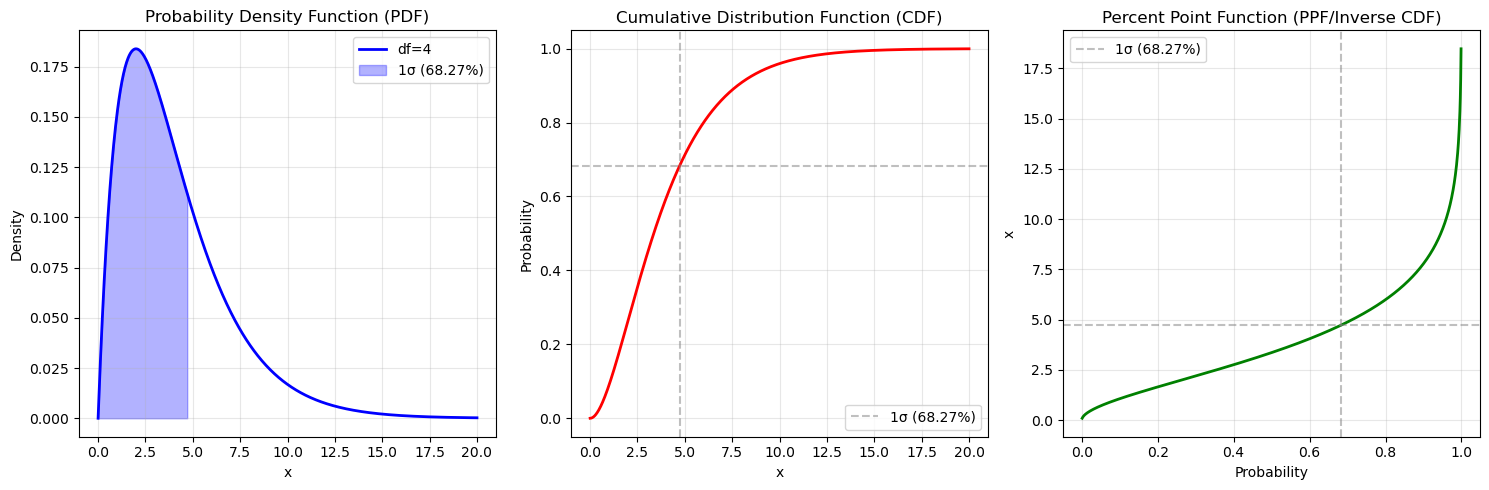


Critical values for different sigma levels (df=4):
1σ (68.27%): 4.720
2σ (95.45%): 9.716
3σ (99.73%): 16.251


In [48]:
from scipy import stats

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Generate x values for plotting
x = np.linspace(0, 20, 1000)
p = np.linspace(0.001, 0.999, 1000)  # for PPF, avoid 0 and 1

# Plot PDF (Probability Density Function)
df = 4  # degrees of freedom
pdf = stats.chi2.pdf(x, df)
ax1.plot(x, pdf, 'b-', lw=2, label=f'df={df}')
ax1.fill_between(x, pdf, where=(x <= stats.chi2.ppf(0.6827, df)), 
                 alpha=0.3, color='blue', label='1σ (68.27%)')
ax1.set_title('Probability Density Function (PDF)')
ax1.set_xlabel('x')
ax1.set_ylabel('Density')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot CDF (Cumulative Distribution Function)
cdf = stats.chi2.cdf(x, df)
ax2.plot(x, cdf, 'r-', lw=2)
ax2.axhline(y=0.6827, color='gray', linestyle='--', alpha=0.5, label='1σ (68.27%)')
ax2.axvline(x=stats.chi2.ppf(0.6827, df), color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Cumulative Distribution Function (CDF)')
ax2.set_xlabel('x')
ax2.set_ylabel('Probability')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot PPF (Percent Point Function / Inverse CDF)
ppf = stats.chi2.ppf(p, df)
ax3.plot(p, ppf, 'g-', lw=2)
ax3.axvline(x=0.6827, color='gray', linestyle='--', alpha=0.5, label='1σ (68.27%)')
ax3.axhline(y=stats.chi2.ppf(0.6827, df), color='gray', linestyle='--', alpha=0.5)
ax3.set_title('Percent Point Function (PPF/Inverse CDF)')
ax3.set_xlabel('Probability')
ax3.set_ylabel('x')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Adjust layout
plt.tight_layout()
plt.show()

# Print some key values
sigma_levels = [0.6827, 0.9545, 0.9973]  # 1σ, 2σ, 3σ
print("\nCritical values for different sigma levels (df=4):")
for i, level in enumerate(sigma_levels, 1):
    critical_value = stats.chi2.ppf(level, df)
    print(f"{i}σ ({level*100:.2f}%): {critical_value:.3f}")

Draw contour plot

C:\Users\klera\AppData\Local\Temp\ipykernel_9988\1615040619.py:22: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
C:\Users\klera\AppData\Local\Temp\ipykernel_9988\1615040619.py:44: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))


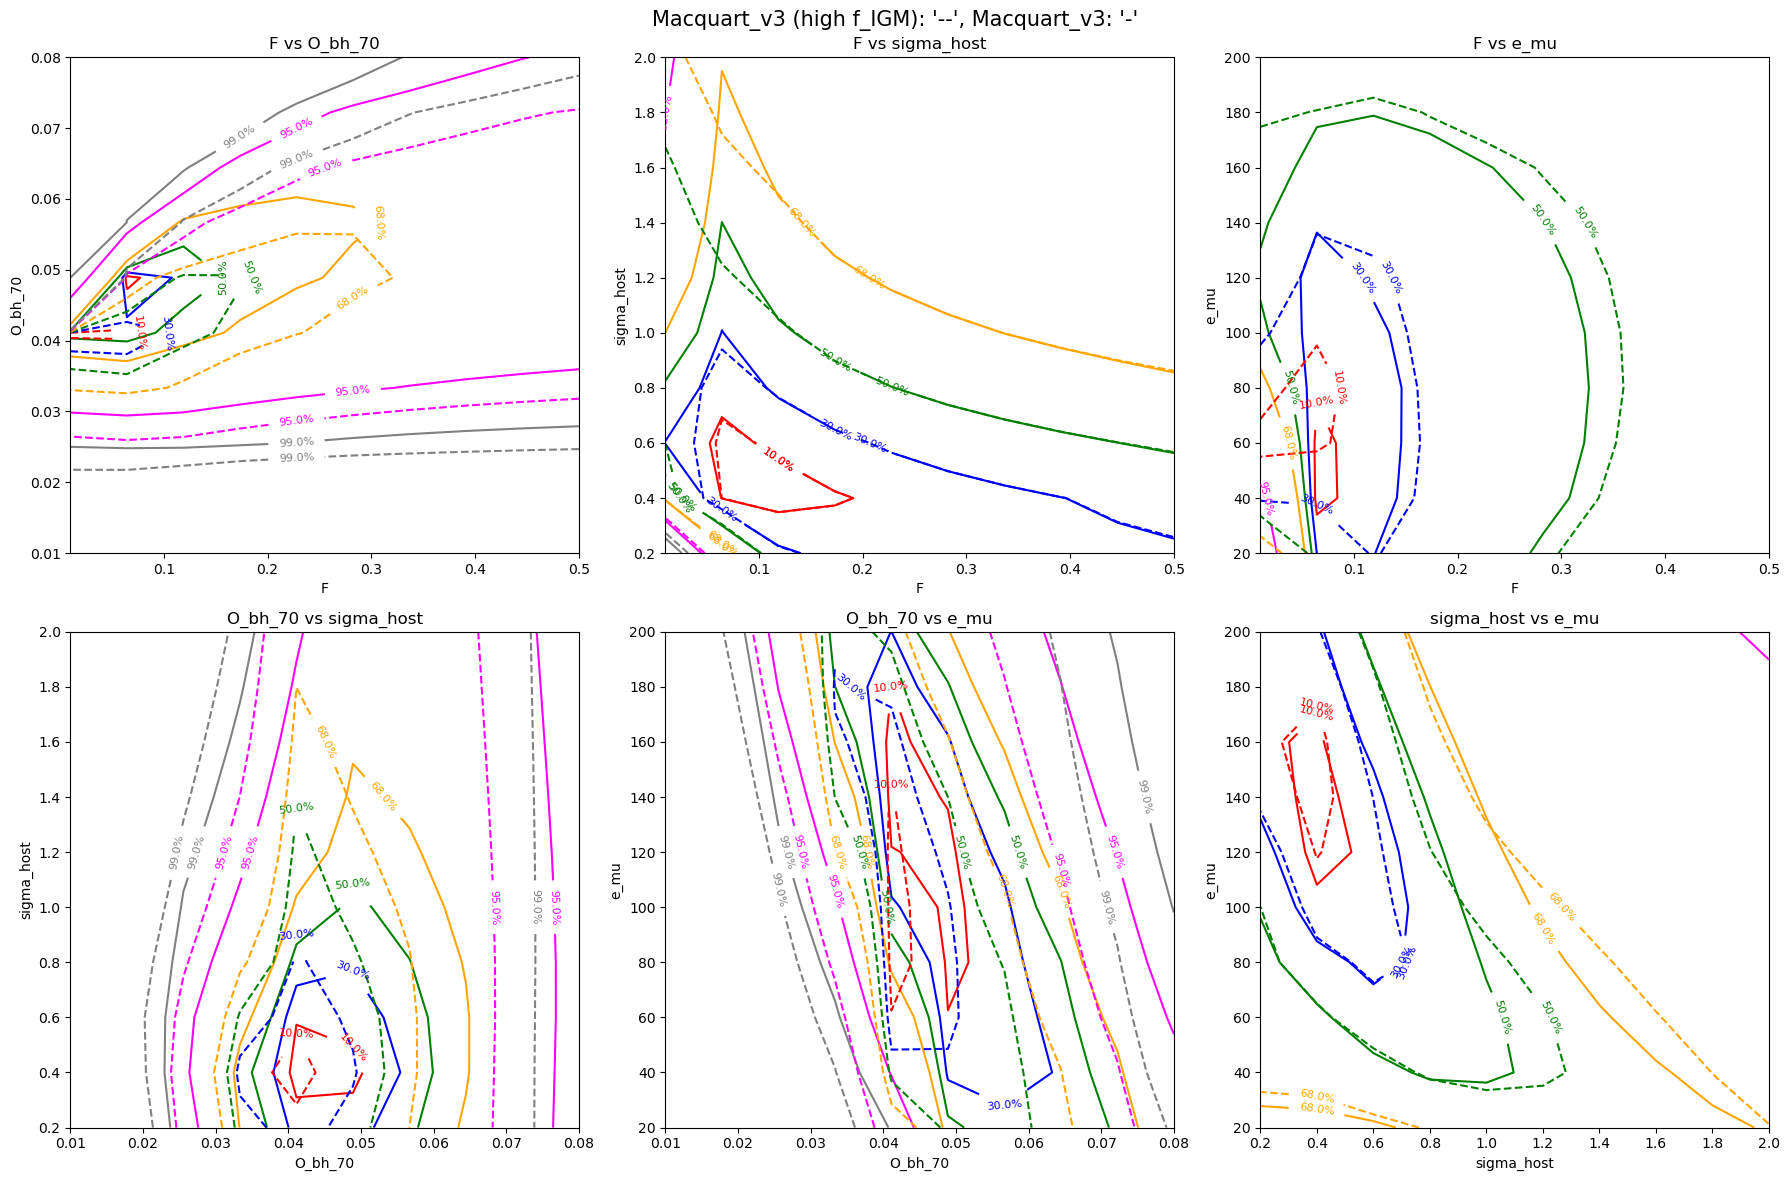

In [89]:
from scipy.stats import chi2

confidence_levels = [0.1,0.3,0.5,0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    ("F", "O_bh_70", (2, 3), F_h, h_F),
    ("F", "sigma_host", (1, 3), F_sigma, sigma_F),
    ("F", "e_mu", (1, 2), F_e_mu, e_mu_F),
    ("O_bh_70", "sigma_host", (0, 3), h_sigma, sigma_h),
    ("O_bh_70", "e_mu", (0, 2), h_e_mu, e_mu_h),
    ("sigma_host", "e_mu", (0, 1), sigma_e_mu, e_mu_sigma)
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D_v4, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]
    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g', 'orange', 'magenta', 'grey'])
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%',
           contour_levels[3]: f'{confidence_levels[3]*100}%',
           contour_levels[4]: f'{confidence_levels[4]*100}%',
           contour_levels[5]: f'{confidence_levels[5]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=8)

    
for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D_v3, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]
    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, linestyles='dashed', colors=['r', 'b', 'g', 'orange', 'magenta', 'grey'])
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%',
           contour_levels[3]: f'{confidence_levels[3]*100}%',
           contour_levels[4]: f'{confidence_levels[4]*100}%',
           contour_levels[5]: f'{confidence_levels[5]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=8)    

fig.suptitle("Macquart_v3 (high f_IGM): '--', Macquart_v3: '-'", fontsize=15)
plt.tight_layout()
plt.show()

# MCMC method

Not complete. Just check the part upper. Since efficiency is enough, MCMC may no need for the project.

In [ ]:
data.head()

In [ ]:
import numpyro
import numpyro.distributions as dist
from numpyro import sample
import jax.numpy as jnp
from jax import vmap, jit
import jax
from jax.scipy.special import erf

In [ ]:
@jit
def pdf_DM_host_jax(DM, e_mu, sigma_host):
    """
    Calculate the probability density function for host DM
    
    Args:
        DM: Host dispersion measure
        e_mu: Mean of log-normal distribution
        sigma_host: Standard deviation of host DM distribution
    
    Returns:
        Probability density value
    """
    mu = jnp.log(e_mu)
    pdf = jnp.exp(-(jnp.log(DM) - mu)**2 / (2 * sigma_host**2)) / (sigma_host * jnp.sqrt(2 * PI) * DM)
    return pdf

@jit
def f_sigma_DM_jax(F, z):
    """
    Calculate sigma_DM as function of redshift
    
    Args:
        F: Structure factor parameter
        z: Redshift
    
    Returns:
        sigma_DM value
    """
    return F * z**-0.5

@jit
def pdf_DM_cosmo_jax(DM, C_0, A, F, z, alpha=3.0):
    """
    Calculate the probability density function for cosmological DM
    
    Args:
        DM: Dispersion measure
        C_0: C_0 parameter
        A: Normalization factor
        F: Structure factor
        z: Redshift
        alpha: Alpha parameter (default: 3.0)
    
    Returns:
        Probability density value
    """
    beta = alpha #(alpha + 1) / (alpha - 1)
    sigma_DM = f_sigma_DM_jax(F, z)
    pdf = A * DM**(-beta) * jnp.exp(-(DM**(-alpha) - C_0)**2 / (2 * alpha**2 * sigma_DM**2))
    return pdf

In [ ]:
@jit
def integrate_pdf_cosmo(C_0, A, F, z, alpha=3.0):
    """
    Numerical integration of pdf_DM_cosmo
    """
    # Use a reasonable range for integration
    x = jnp.logspace(-3, 5, 1000) # from 1/10 to 10**3
    dx = x[1:] - x[:-1]
    
    # Calculate pdf values
    pdf_values = pdf_DM_cosmo_jax(x, C_0, A, F, z, alpha)
    # Calculate x*pdf values
    x_pdf_values = x * pdf_values
    
    # Compute integrals using trapezoidal rule
    integral_pdf = jnp.sum(0.5 * (pdf_values[1:] + pdf_values[:-1]) * dx)
    integral_x_pdf = jnp.sum(0.5 * (x_pdf_values[1:] + x_pdf_values[:-1]) * dx)
    
    return integral_pdf, integral_x_pdf

@jit
def c0_objective(C_0, F, z, alpha=3.0):
    """
    Objective function for finding C_0: int(x*p(x)dx) - int(p(x)dx) = 0
    """
    # Use A=1 initially since it's just a scaling factor
    integral_pdf, integral_x_pdf = integrate_pdf_cosmo(C_0, 1.0, F, z, alpha)
    return integral_x_pdf - integral_pdf

@jit
def find_c0_jax(F, z, alpha=3.0, num_iterations=500):
    """
    Find C_0 using fixed-point iteration
    """
    # Initial guess
    c0 = 0
    learning_rate = 0.1
    
    def body_fun(i, c0):
        obj_val = c0_objective(c0, F, z, alpha)
        # Update C_0 using gradient descent
        c0 = c0 + learning_rate * obj_val
        return c0
    
    c0 = jax.lax.fori_loop(0, num_iterations, body_fun, c0)
    return c0

@jit
def find_a_jax(C_0, F, z, alpha=3.0):
    """
    Find normalization factor A
    """
    # Calculate integral with A=1
    integral_pdf, _ = integrate_pdf_cosmo(C_0, 1.0, F, z, alpha)
    # A should be 1/integral
    return 1.0 / integral_pdf

@jit
def DM_IGM_O_bh_70_jax(z, O_bh_70, Om=OMEGA_MATTER, w=-1.0):
    """
    Calculate IGM DM contribution
    
    Args:
        z: Redshift
        O_bh_70: Baryon density parameter
        Om: Omega matter (default: OMEGA_MATTER)
        w: Dark energy EoS parameter (default: -1.0)
    
    Returns:
        IGM DM value
    """
    O_bH_0 = O_bh_70 * 70
    factor = 3 * C_LIGHT * KM_2_MPC * O_bH_0 * f_IGM / (8 * PI * G_NEWTON * M_PROTON) * (7/8)
    
    # Simplified integration for JAX compatibility
    # Note: This is an approximation of the original quad integration

    x = jnp.linspace(0, z, 1000)
    dx = x[1] - x[0]
    integrand = (1+x) / jnp.sqrt(Om * (1 + x)**3 + (1 - Om) * (1 + x)**(3 * (1 + w)))
    integral = jnp.sum(integrand) * dx
    
    return DM_2_PCCM3 * factor * integral

In [ ]:
@jit
def calculate_dm_probability_jax(DM_frb, z, F, O_bh_70, sigma_host, e_mu):
    """
    Calculate the probability of DM_FRB given various cosmological parameters
    """
    # Find C_0 and A
    C_0 = find_c0_jax(F, z)
    A = find_a_jax(C_0, F, z)
    
    # Parameters for numerical integration
    DM_host_values = jnp.linspace(0, DM_frb, 1000)
    dDM = DM_host_values[1] - DM_host_values[0]
    
    # Calculate host contribution
    p_host = pdf_DM_host_jax(DM_host_values, e_mu, sigma_host)
    
    # Calculate delta parameter
    delta = (DM_frb - DM_host_values/(1 + z)) / DM_IGM_O_bh_70_jax(z=z, O_bh_70=O_bh_70)
    
    # Calculate cosmic contribution
    p_cosmic = pdf_DM_cosmo_jax(delta, C_0, A, F, z)
    
    # Numerical integration
    integrand = p_host * p_cosmic
    result = jnp.sum(integrand) * dDM
    
    return result

# Vectorized version for batch processing
batch_calculate_dm_probability = vmap(calculate_dm_probability_jax, in_axes=(0, 0, None, None, None, None))

In [ ]:
def frb_model(data):
    # proior
    F = sample("F", dist.Uniform(F_array.min(), F_array.max()))
    O_bh_70 = sample("O_bh_70", dist.Uniform(O_bh_70_array.min(), O_bh_70_array.max()))
    sigma_host = sample("sigma_host", dist.Uniform(sigma_host_array.min(), sigma_host_array.max()))
    e_mu = sample("e_mu", dist.Uniform(e_mu_array.min(), e_mu_array.max()))
    
    # use vmap to calculate the probability of each FRB
    def prob_single_frb(frb_data):
        return calculate_dm_probability_jax(
            DM_frb=frb_data['DM_'],
            z=frb_data['z'],
            F=F,
            O_bh_70=O_bh_70,
            sigma_host=sigma_host,
            e_mu=e_mu
        )
    
    # Change the data format to a dictionary
    frb_data_dict = {
        'DM_': jnp.array(data['DM_']),
        'z': jnp.array(data['z'])
    }
    
    # Calculate the probability of each FRB using vmap
    log_probs = vmap(prob_single_frb)(frb_data_dict)
    total_log_prob = jnp.sum(jnp.log(log_probs))
    
    # Set the observation likelihood
    numpyro.factor("obs", total_log_prob)

In [ ]:
# Setup the MCMC sampler
def run_mcmc(data, num_warmup=2000, num_samples=2000, num_chains=2):
    kernel = numpyro.infer.NUTS(frb_model)
    mcmc = numpyro.infer.MCMC(
        kernel,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains
    )
    
    mcmc.run(jax.random.PRNGKey(0), data=data)
    return mcmc

# Usage example
if __name__ == "__main__":
    numpyro.set_host_device_count(2)
    
    mcmc = run_mcmc(data)
    
    # retrieve the samples
    %time samples = mcmc.get_samples()
    
    mcmc.print_summary()

In [ ]:
import corner
from matplotlib.colors import LogNorm
import arviz as az

In [ ]:
inf_data = az.from_numpyro(mcmc)
az.summary(inf_data)

In [ ]:
figure = corner.corner(
    inf_data, 
    # truths={"F": F, "O_bh_70": O_bh_70, "e_mu":e_mu, "sigma_host": sigma_host}, 
    smooth=True, 
    fill_contours=True, 
    color='tab:blue', 
    truth_color='tab:red', 
    levels=(0.68, 0.95, 0.99)
    )

In [ ]:
# transfer samples to numpy
inf_data = np.vstack([
    samples['F'],
    samples['O_bh_70'], 
    samples['sigma_host'],
    samples['e_mu']
]).T

# set labels
labels = [r'$F$', r'$\Omega_{b,0}h_{70}$', r'$\sigma_{\rm host}$', r'$e^{\mu}$']

# corner plot
figure = corner.corner(
    inf_data,
    labels=labels,
    smooth=True,
    fill_contours=True,
    color='tab:blue',
    levels=(0.68, 0.95, 0.99)
)

# plt.savefig('corner_plot.png', dpi=300, bbox_inches='tight')